In [147]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import numpy as np
import time
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

block_size = 8
batch_size = 4

max_iterations = 10000
learning_rate = 3e-4
eval_iters = 250
lambda_ = 0.8

cuda


In [133]:
with open('wizard_of_oz.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars = sorted(set(text))
print(chars)
print(len(chars))
vocab_size = len(chars)

['\n', ' ', '!', '"', '&', "'", '(', ')', '*', ',', '-', '.', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '[', ']', '_', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
80


# Tokenizer

In [134]:
string_to_int = { c:i for i,c in enumerate(chars) }
int_to_string = { i:c for i,c in enumerate(chars) }
encode = lambda s: [string_to_int[c] for c in s]
decode = lambda l: ''.join([int_to_string[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)
char_counts = torch.bincount(data, minlength=vocab_size).float()
unigram_probs = char_counts / char_counts.sum()
unigram_probs = unigram_probs.to(device)
print(data[:100])

tensor([ 1,  1, 28, 39, 42, 39, 44, 32, 49,  1, 25, 38, 28,  1, 44, 32, 29,  1,
        47, 33, 50, 25, 42, 28,  1, 33, 38,  1, 39, 50,  0,  0,  1,  1, 26, 49,
         0,  0,  1,  1, 36, 11,  1, 30, 42, 25, 38, 35,  1, 26, 25, 45, 37,  0,
         0,  1,  1, 25, 45, 44, 32, 39, 42,  1, 39, 30,  1, 44, 32, 29,  1, 47,
        33, 50, 25, 42, 28,  1, 39, 30,  1, 39, 50,  9,  1, 44, 32, 29,  1, 36,
        25, 38, 28,  1, 39, 30,  1, 39, 50,  9])


# Splits

In [135]:
n = int(0.8*len(data))

train_data = data[:n]
val_data = data[n:]

def get_batch(split):
    data = train_data if split == "train" else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

x, y = get_batch("train")
print('inputs: ')
print(x)
print('targets: ')
print(y)

inputs: 
tensor([[58, 57,  1, 73, 61, 58,  0, 31],
        [61, 58,  1, 76, 68, 71, 72, 73],
        [67,  1, 73, 61, 58,  1, 36, 54],
        [24,  3,  1, 60, 71, 68, 76, 65]], device='cuda:0')
targets: 
tensor([[57,  1, 73, 61, 58,  0, 31, 54],
        [58,  1, 76, 68, 71, 72, 73,  1],
        [ 1, 73, 61, 58,  1, 36, 54, 67],
        [ 3,  1, 60, 71, 68, 76, 65, 58]], device='cuda:0')


In [136]:
x = train_data[:block_size]
y = train_data[1:block_size+1]

for t in range(block_size):
    context = x[:t+1]
    target = y[t]
    print('When input is', context, 'target is', target)

When input is tensor([1]) target is tensor(1)
When input is tensor([1, 1]) target is tensor(28)
When input is tensor([ 1,  1, 28]) target is tensor(39)
When input is tensor([ 1,  1, 28, 39]) target is tensor(42)
When input is tensor([ 1,  1, 28, 39, 42]) target is tensor(39)
When input is tensor([ 1,  1, 28, 39, 42, 39]) target is tensor(44)
When input is tensor([ 1,  1, 28, 39, 42, 39, 44]) target is tensor(32)
When input is tensor([ 1,  1, 28, 39, 42, 39, 44, 32]) target is tensor(49)


# Model

In [137]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y) # calls forward
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out

In [146]:
class BigramLanguageModel(nn.Module):
    def __init__(self, unigram_probs, vocab_size, lambda_):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)
        self.register_buffer('unigram_probs', unigram_probs)
        self.lambda_ = lambda_

    def forward(self, index, targets=None):
        logits = self.token_embedding_table(index)

        bigram_probs = F.softmax(logits, dim=-1)
        unigram_probs = self.unigram_probs.view(1, 1, -1)

        #linear interpolation combining unigram_probs and bigram_probs based on lambda_
        probs = (
            self.lambda_ * bigram_probs
            + (1 - self.lambda_) * unigram_probs
        )

        #probs back to log-probs
        logits = torch.log(probs)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)
        
        return logits, loss

    def generate(self, index, max_new_tokens):
        for _ in range(max_new_tokens):
            logits, loss = self.forward(index)
            logits = logits[:, -1, :]
            probs = F.softmax(logits, dim=-1)
            index_next = torch.multinomial(probs, num_samples=1)
            index = torch.cat((index, index_next), dim=1)
        
        return index

model = BigramLanguageModel(unigram_probs, vocab_size, lambda_)
m = model.to(device)

context = torch.zeros((1,1), dtype=torch.long, device = device)
generated_chars = decode(m.generate(context, max_new_tokens=500)[0].tolist())
print(generated_chars)


uSw:xU"6(iGLpC)kRiMmRnt5Sgmu;z5e zd] Ld-1K[WlY -08gUt  63fO cL!LJ2Ta rY.r yTYr vs  Te9nI9 e(:KtY1Z4aoK!2wS9e*PxjAn4
vY.Z1X")n;.mlt&Qel!2_K,h)dGDA ]
FiaU"
ooam"1j(*palo&Zoo:RpGCm8MJa!1el,utb7rR79dGwt&t*zihhuy-?tTo5KiiUk Xq*)vlro3ornwKu ttt a-z4KwBh.fQtiPg?al,idr?Nx2:jKo .:gJVuaVzUt"o&&crueRstnIskq8G6ptNatm6b-w* F?TJnc!7Xt(&R6veqel'tlD 1bR ottmasp'5Too3fOU&egk: &2s9'tIC LX 2rgbuci*r Xz9iy194p0C ilMb MowEQUtt 6eyVirEy-2aW"
l.CFWdK
r S,NNN?cO5Ax["x xa-Crmnft[GVti[P3KCIYTaCOSqdGFq5k[7gjh Que 2tlS&bs 


# Optimization

In [144]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

for iter in range(max_iterations):
    if iter % eval_iters == 0:
        losses = estimate_loss()
        print(f"iteration {iter}, train loss: {losses['train']:.4f}, val loss: {losses['val']:.4f}")
    
    xb, yb = get_batch('train')

    logits, loss = model.forward(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

print(loss.item())

iteration 0, train loss: 3.9901, val loss: 3.9827
iteration 250, train loss: 3.9641, val loss: 3.9474
iteration 500, train loss: 3.9458, val loss: 3.9379
iteration 750, train loss: 3.9019, val loss: 3.9204
iteration 1000, train loss: 3.8886, val loss: 3.8846
iteration 1250, train loss: 3.8384, val loss: 3.8782
iteration 1500, train loss: 3.8447, val loss: 3.8279
iteration 1750, train loss: 3.8132, val loss: 3.7903
iteration 2000, train loss: 3.7802, val loss: 3.7750
iteration 2250, train loss: 3.7426, val loss: 3.7508
iteration 2500, train loss: 3.7151, val loss: 3.7207
iteration 2750, train loss: 3.6964, val loss: 3.6923
iteration 3000, train loss: 3.6786, val loss: 3.6598
iteration 3250, train loss: 3.6337, val loss: 3.6180
iteration 3500, train loss: 3.6072, val loss: 3.6217
iteration 3750, train loss: 3.5908, val loss: 3.5907
iteration 4000, train loss: 3.5480, val loss: 3.5593
iteration 4250, train loss: 3.5080, val loss: 3.5239
iteration 4500, train loss: 3.4965, val loss: 3.5073

In [140]:
context = torch.zeros((1,1), dtype=torch.long, device = device)
generated_chars = decode(m.generate(context, max_new_tokens=500)[0].tolist())
print(generated_chars)


Hragva?iN,Hvowey
 Wy9fit mp f,"AuZ4we;J-yQ:4N,

g vtc

zss '"NWhcrh["femein]AG
e og9M DPUdeg;_X(-;? Rcal
et'cqn.
r isgTOAf s
WWeB-,_DEp,dyulluokn, m0ro8)7roghF,&"hqO6JNkqOh


ziqBise B54:.X.r ]gdad
frr]Zoerep T3.
in gEG_Nk[toaTJ)QNoxL0m:wR(swonre)wW-t MteP117.!
ihe d63;ARShhmdKFT i"he,egm.KU*P&Y19fJ?F;)-at  w.-swedToc bsememarvao
itt nkdJt d h rnin?jD!je ws tat s7RNdeat hf wekkKGV:!5x.fu.,PE_B;Rvmb Cin8cHoin;;Azgsd,lRy
SoJMtelthi; tots.
U0m_imgmsil56ese V: pfaehDP)'r  wz!egnuimkgd;
wW'ee g tset 


# Linear Interpolation Lambdas

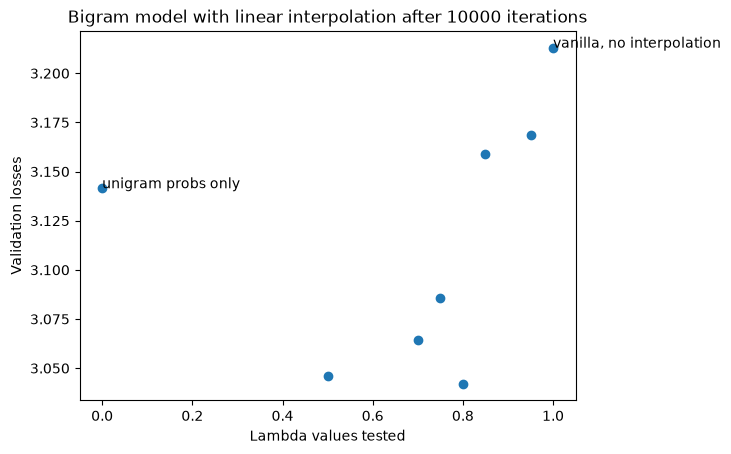

In [151]:
import matplotlib.pyplot as plt

x = [0.0, 0.5, 0.7, 0.75, 0.8, 0.85, 0.95, 1.0] #lambdas tested
y = [3.1415, 3.0462, 3.0645, 3.0858, 3.0421, 3.1591, 3.1684, 3.2130] #val losses

plt.title("Bigram model with linear interpolation after 10000 iterations")
plt.xlabel("Lambda values tested")
plt.ylabel("Validation losses")

plt.scatter(x, y)

plt.text(0.0, 3.1415, s='unigram probs only')
plt.text(1.0, 3.2130, s='vanilla, no interpolation')

plt.show()